Name : Arpita Hanwatkar

Section : B2

Batch : B1

Roll No. : 04

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

In [3]:
df = pd.read_csv("insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Number of observations:", len(df))
print("Number of variables:", len(df.columns))

print("\nShape:")
print(df.shape)

print("\nDataset Information:")
df.info()

Number of observations: 1338
Number of variables: 7

Shape:
(1338, 7)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


In [6]:
print(df.describe(include='object'))

         sex smoker     region
count   1338   1338       1338
unique     2      2          4
top     male     no  southeast
freq     676   1064        364


In [7]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [8]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 1


In [9]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


In [10]:
print("Sex:", df['sex'].unique())
print("Smoker:", df['smoker'].unique())
print("Region:", df['region'].unique())


Sex: ['female' 'male']
Smoker: ['yes' 'no']
Region: ['southwest' 'southeast' 'northwest' 'northeast']


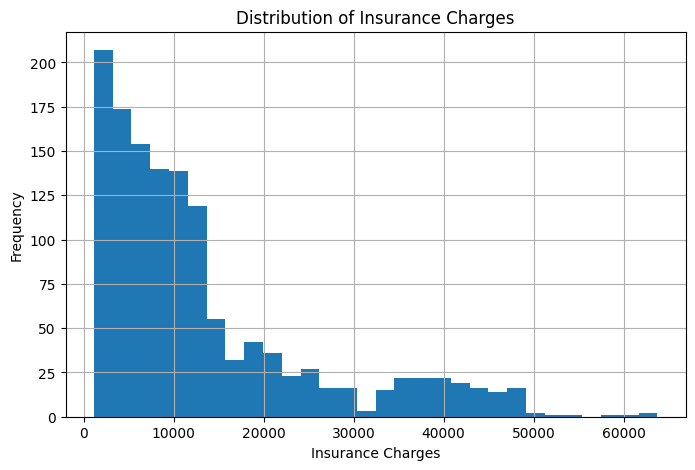

In [11]:
plt.figure(figsize=(8,5))

plt.hist(df['charges'], bins=30)

plt.xlabel("Insurance Charges")
plt.ylabel("Frequency")
plt.title("Distribution of Insurance Charges")

plt.grid()
plt.show()

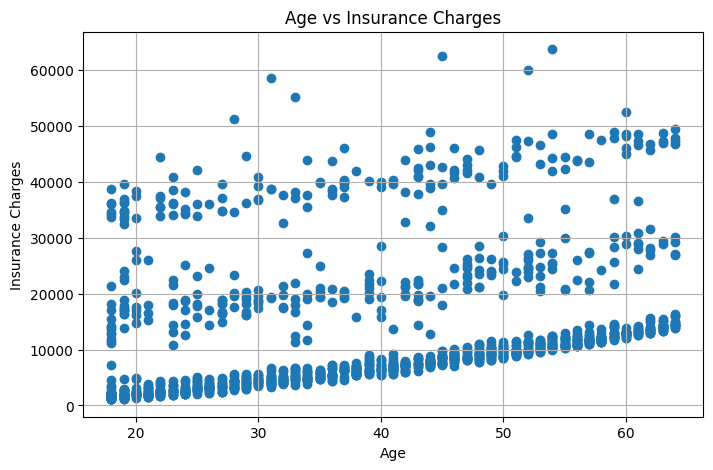

In [12]:
plt.figure(figsize=(8,5))

plt.scatter(df['age'], df['charges'])

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Age vs Insurance Charges")

plt.grid()
plt.show()

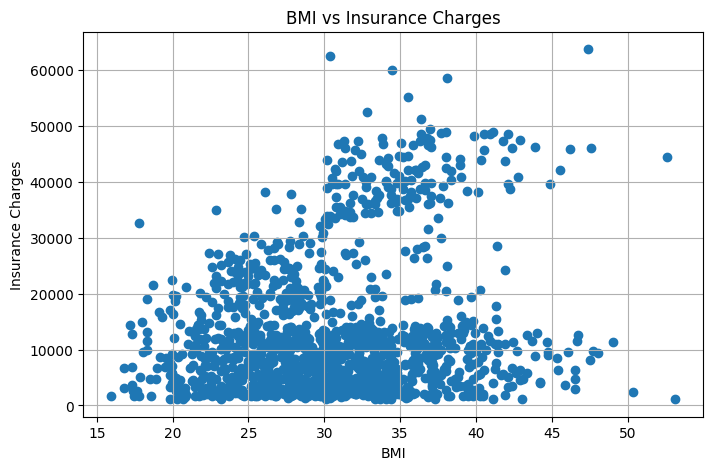

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(df['bmi'], df['charges'])

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("BMI vs Insurance Charges")

plt.grid()
plt.show()

<Figure size 700x500 with 0 Axes>

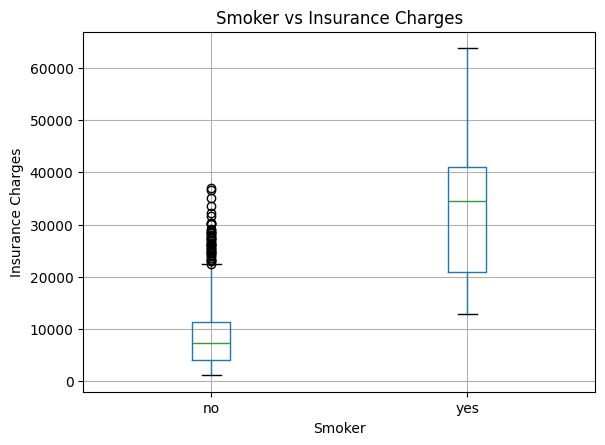

In [14]:
plt.figure(figsize=(7,5))

df.boxplot(column='charges', by='smoker')

plt.xlabel("Smoker")
plt.ylabel("Insurance Charges")
plt.title("Smoker vs Insurance Charges")

plt.suptitle("")
plt.show()

In [15]:
print(df.groupby('smoker')['charges'].mean())

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64


In [16]:
print(df.groupby('region')['charges'].mean())

region
northeast    13406.384516
northwest    12450.840844
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64


In [17]:
print(df.groupby('sex')['charges'].mean())

sex
female    12569.578844
male      13974.998864
Name: charges, dtype: float64


In [18]:
numeric_df = df.select_dtypes(include=np.number)

print(numeric_df.corr())

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


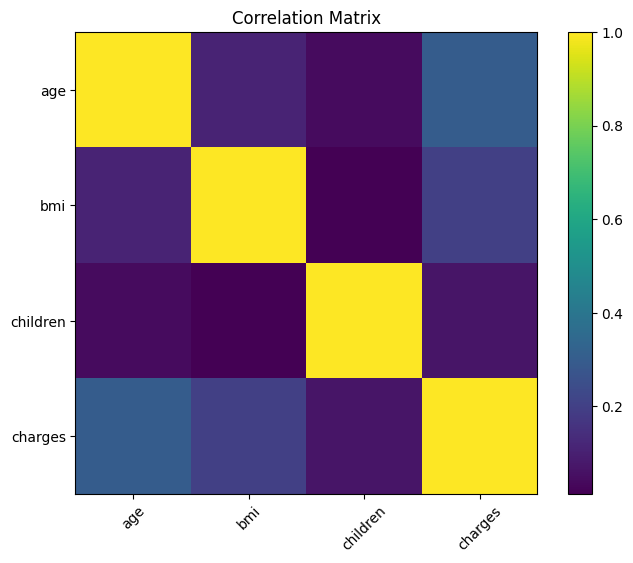

In [19]:
plt.figure(figsize=(8,6))

corr = numeric_df.corr()

plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

In [20]:
X = df.drop('charges', axis=1)
y = df['charges']

print(X.head())
print(y.head())

   age     sex     bmi  children smoker     region
0   19  female  27.900         0    yes  southwest
1   18    male  33.770         1     no  southeast
2   28    male  33.000         3     no  southeast
3   33    male  22.705         0     no  northwest
4   32    male  28.880         0     no  northwest
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [21]:
numerical_features = ['age', 'bmi', 'children']

categorical_features = ['sex', 'smoker', 'region']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1069
Testing samples: 268


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),

        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ), categorical_features)
    ]
)

In [24]:
linear_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_test)

print("Multiple Linear Regression trained successfully")

Multiple Linear Regression trained successfully


In [25]:
ridge_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Ridge(alpha=1.0))
    ]
)

ridge_model.fit(X_train, y_train)

ridge_pred = ridge_model.predict(X_test)

print("Ridge Regression trained successfully")

Ridge Regression trained successfully


In [26]:
lasso_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('model', Lasso(alpha=1.0, max_iter=10000))
    ]
)

lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

print("Lasso Regression trained successfully")

Lasso Regression trained successfully


In [27]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features),

        ('cat', OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ), categorical_features)
    ]
)

In [28]:
tree_model = Pipeline(
    steps=[
        ('preprocessor', tree_preprocessor),

        ('model', DecisionTreeRegressor(
            max_depth=5,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree Regression trained successfully")

Decision Tree Regression trained successfully


In [29]:
forest_model = Pipeline(
    steps=[
        ('preprocessor', tree_preprocessor),

        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=8,
            random_state=42
        ))
    ]
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest Regression trained successfully")

Random Forest Regression trained successfully


In [30]:
predictions = {
    'Multiple Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'Decision Tree Regression': tree_pred,
    'Random Forest Regression': forest_pred
}

In [31]:
results = []

for model_name, prediction in predictions.items():

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, prediction)

    results.append(
        [model_name, mae, mse, rmse, r2]
    )

In [32]:
results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'MSE',
        'RMSE',
        'R2 Score'
    ]
)

print("\nModel Performance Comparison")
print("=" * 85)

print(
    results_df.round(4).to_string(index=False)
)


Model Performance Comparison
                     Model       MAE          MSE      RMSE  R2 Score
Multiple Linear Regression 4177.0456 3.547802e+07 5956.3429    0.8069
          Ridge Regression 4193.8919 3.566313e+07 5971.8617    0.8059
          Lasso Regression 4177.7781 3.549317e+07 5957.6149    0.8068
  Decision Tree Regression 2656.8391 1.946166e+07 4411.5376    0.8941
  Random Forest Regression 2495.7304 2.000005e+07 4472.1414    0.8912


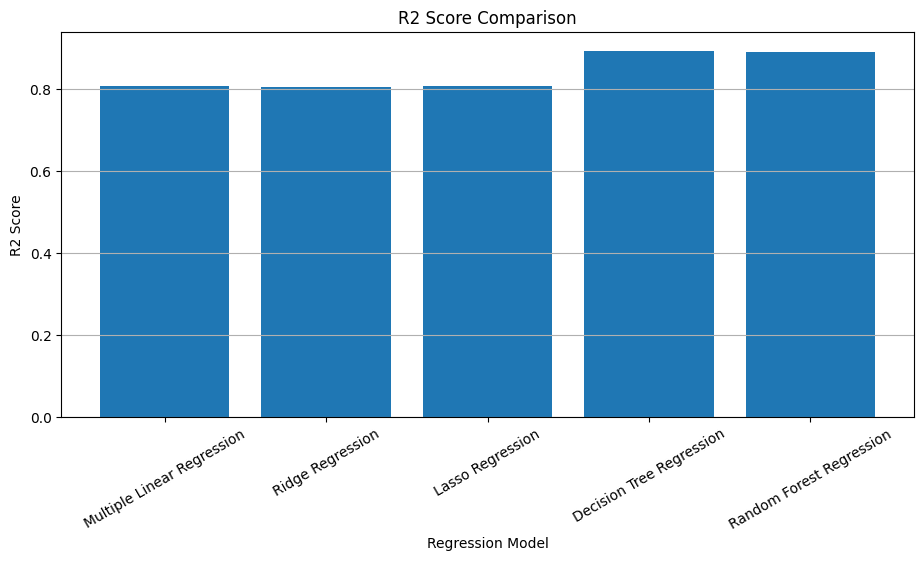

In [33]:
plt.figure(figsize=(11,5))

plt.bar(
    results_df['Model'],
    results_df['R2 Score']
)

plt.xlabel("Regression Model")
plt.ylabel("R2 Score")

plt.title("R2 Score Comparison")

plt.xticks(rotation=30)

plt.grid(axis='y')

plt.show()

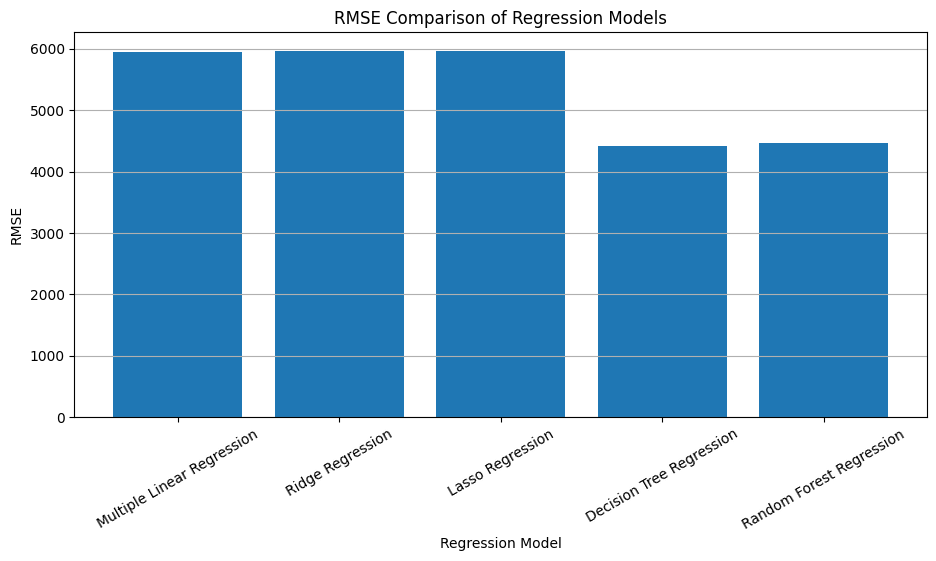

In [34]:
plt.figure(figsize=(11,5))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.xlabel("Regression Model")
plt.ylabel("RMSE")

plt.title("RMSE Comparison of Regression Models")

plt.xticks(rotation=30)

plt.grid(axis='y')

plt.show()

In [35]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Linear Regression': linear_pred,
    'Ridge Regression': ridge_pred,
    'Lasso Regression': lasso_pred,
    'Decision Tree Regression': tree_pred,
    'Random Forest Regression': forest_pred
})

print(comparison.head(10).round(2))

   Actual Charges  Linear Regression  Ridge Regression  Lasso Regression  \
0         8688.86            8143.69           8170.65           8137.41   
1         5708.87            5737.12           5767.79           5740.23   
2        11436.74           14369.31          14379.97          14367.41   
3        38746.36           31745.51          31637.01          31743.27   
4         4463.21            8962.39           9003.53           8967.77   
5         9304.70           13149.72          13185.64          13154.62   
6        38511.63           30446.76          30326.06          30423.16   
7         2150.47            1453.29           1484.47           1460.14   
8         7345.73           10633.02          10661.93          10634.92   
9        10264.44           11318.94          11345.89          11324.88   

   Decision Tree Regression  Random Forest Regression  
0                  12504.99                   9627.41  
1                   9511.51                   8703.

In [36]:
best_model_name = results_df.loc[
    results_df['R2 Score'].idxmax()
]['Model']

print("Best Performing Model:", best_model_name)

Best Performing Model: Decision Tree Regression


In [37]:
models = {
    'Multiple Linear Regression': linear_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Decision Tree Regression': tree_model,
    'Random Forest Regression': forest_model
}

In [38]:
best_model = models[best_model_name]

print(best_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('model', DecisionTreeRegressor(max_depth=5, random_state=42))])


In [39]:
best_row = results_df.loc[
    results_df['R2 Score'].idxmax()
]

print("\nBest Model")
print("=" * 50)

print("Model:", best_row['Model'])
print("MAE:", round(best_row['MAE'], 2))
print("MSE:", round(best_row['MSE'], 2))
print("RMSE:", round(best_row['RMSE'], 2))
print("R2 Score:", round(best_row['R2 Score'], 4))


Best Model
Model: Decision Tree Regression
MAE: 2656.84
MSE: 19461664.32
RMSE: 4411.54
R2 Score: 0.8941


In [40]:
joblib.dump(
    best_model,
    "insurance_model.pkl"
)

print("Best model saved successfully")

Best model saved successfully


In [41]:
new_customer = pd.DataFrame({
    'age': [30],
    'sex': ['female'],
    'bmi': [28.5],
    'children': [1],
    'smoker': ['no'],
    'region': ['southeast']
})

In [42]:
prediction = best_model.predict(new_customer)

print(
    "Predicted Insurance Charges:",
    round(prediction[0], 2)
)

Predicted Insurance Charges: 6562.5


In [43]:
model = joblib.load(
    "insurance_model.pkl"
)

In [44]:
prediction = model.predict(new_customer)

print(
    "Predicted Insurance Charges:",
    round(prediction[0], 2)
)

Predicted Insurance Charges: 6562.5


In [47]:
import pandas as pd

def predict_charges(age, sex, bmi, children, smoker, region):

    input_data = pd.DataFrame({
        'age': [age],
        'sex': [sex],
        'bmi': [bmi],
        'children': [children],
        'smoker': [smoker],
        'region': [region]
    })

    prediction = model.predict(input_data)[0]

    return f"Estimated Insurance Charges: ₹ {round(prediction,2)}"

In [48]:
import gradio as gr

interface = gr.Interface(
    fn=predict_charges,

    inputs=[
        gr.Slider(18, 65, step=1, label="Age"),
        gr.Radio(["male", "female"], label="Sex"),
        gr.Slider(10.0, 50.0, step=0.1, label="BMI"),
        gr.Slider(0, 5, step=1, label="Number of Children"),
        gr.Radio(["yes", "no"], label="Smoker"),
        gr.Dropdown(
            ["northeast", "northwest", "southeast", "southwest"],
            label="Region"
        )
    ],

    outputs="text",

    title="Medical Insurance Cost Predictor",

    description="Enter patient details to estimate insurance charges"
)

In [49]:
interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93118c0a10626ef273.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
